In [ ]:
#Importing Libariries
import pandas as pd



In [ ]:
#Loading Data
path="/content/Nassau Candy Distributor.csv"
df=pd.read_csv(path)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [ ]:
#Data Understanding
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [ ]:
df[['order_date', 'ship_date']].head()

,order_date,ship_date
0,03-01-2024,30-06-2026
1,04-01-2024,01-07-2026
2,04-01-2024,01-07-2026
3,04-01-2024,01-07-2026
4,05-01-2024,05-07-2026


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

/tmp/ipykernel_8144/1644255900.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')


In [ ]:
print(df[['order_date', 'ship_date']].isnull().sum())

order_date    6064
ship_date        0
dtype: int64


In [ ]:
df['lead_time'] = (df['ship_date'] - df['order_date']).dt.days

In [ ]:
print(df[['order_date', 'ship_date', 'lead_time']].head())

  order_date  ship_date  lead_time
0 2024-03-01 2026-06-30      851.0
1 2024-04-01 2026-07-01      821.0
2 2024-04-01 2026-07-01      821.0
3 2024-04-01 2026-07-01      821.0
4 2024-05-01 2026-07-05      795.0


In [ ]:
#Importing Visualisation tool
import matplotlib.pyplot as plt

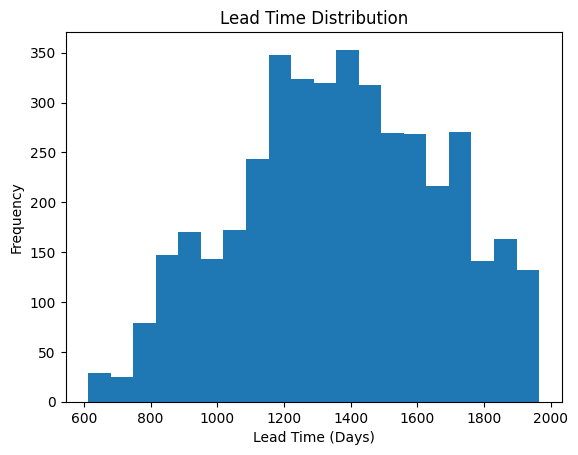

In [ ]:
#Lead Time Distribution (Histogram)
plt.figure()
plt.hist(df['lead_time'], bins=20)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

**Shows** **delays** **&** **consistency**

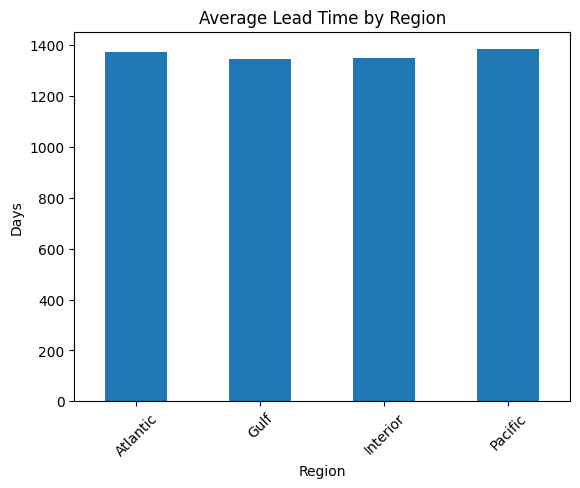

In [ ]:
#Average Lead Time by Region
avg_lead_time = df.groupby('region')['lead_time'].mean()

plt.figure()
avg_lead_time.plot(kind='bar')
plt.title("Average Lead Time by Region")
plt.xlabel("Region")
plt.ylabel("Days")
plt.xticks(rotation=45)
plt.show()

**Which** **regions** **are** **slow**

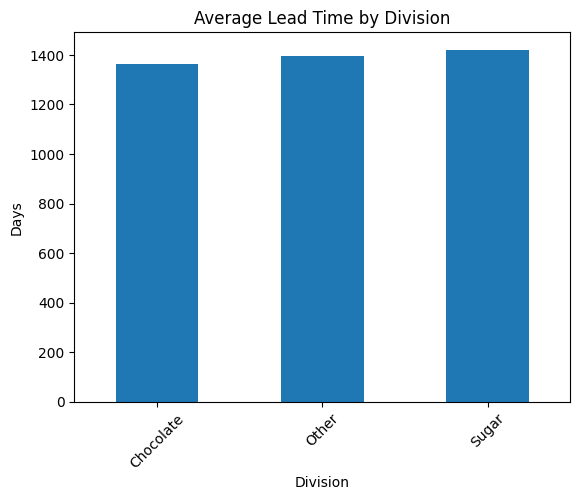

In [ ]:
#Lead Time by Division (Factory Proxy)
avg_division = df.groupby('division')['lead_time'].mean()

plt.figure()
avg_division.plot(kind='bar')
plt.title("Average Lead Time by Division")
plt.xlabel("Division")
plt.ylabel("Days")
plt.xticks(rotation=45)
plt.show()

**Which** **division** **is** **inefficient**

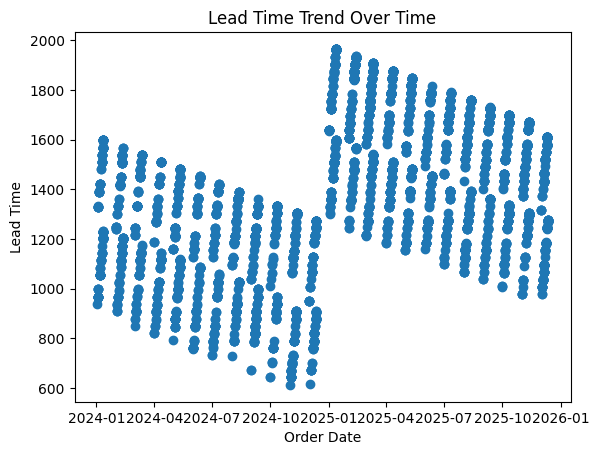

In [ ]:
#Order Date vs Lead Time (Trend)
plt.figure()
plt.scatter(df['order_date'], df['lead_time'])
plt.title("Lead Time Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Lead Time")
plt.show()

**Delay** **patterns** **over** **time**

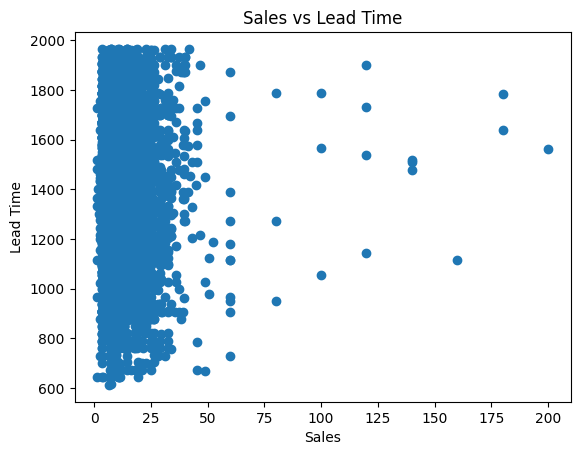

In [ ]:
#Sales vs Lead Time (Business Impact)
plt.figure()
plt.scatter(df['sales'], df['lead_time'])
plt.title("Sales vs Lead Time")
plt.xlabel("Sales")
plt.ylabel("Lead Time")
plt.show()

**Does** **delay** **affect** **revenue**?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [ ]:
y = df['lead_time']

In [ ]:
df['lead_time'] = (df['ship_date'] - df['order_date']).dt.days

In [ ]:
print(df['lead_time'].isnull().sum())

6064


In [ ]:
df = df.dropna(subset=['lead_time'])

In [ ]:
print(df.isnull().sum())

row_id            0
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_id       0
country/region    0
city              0
state/province    0
postal_code       0
division          0
region            0
product_id        0
product_name      0
sales             0
units             0
gross_profit      0
cost              0
lead_time         0
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
df.fillna(0, inplace=True)

In [ ]:
X = df[['sales']]
y = df['lead_time']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predictions
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [ ]:
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [ ]:
# MAE
mae = mean_absolute_error(y_test, y_pred)

In [ ]:
# R2 Score
r2 = r2_score(y_test, y_pred)

In [ ]:
print("Model Evaluation Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

Model Evaluation Metrics:
RMSE: 308.75086626155064
MAE: 253.25681710186248
R2 Score: -0.0055805023733412895


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

def evaluate_model(y_test, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name} Performance:")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2 Score:", r2)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_gb, "Gradient Boosting")


Linear Regression Performance:
RMSE: 308.75086626155064
MAE: 253.25681710186248
R2 Score: -0.0055805023733412895

Random Forest Performance:
RMSE: 313.4790379018198
MAE: 256.8726121045312
R2 Score: -0.0366149905655051

Gradient Boosting Performance:
RMSE: 312.7815456902581
MAE: 256.6188248969197
R2 Score: -0.032007176826343464


In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
